In [8]:
from connection import Connection
import pandas as pd
conn = Connection()
def query_fetch_df(query_str: str, connection=conn):
    """Run a query and return as a pandas DataFrame."""
    return pd.DataFrame(connection.query_fetch(query_str), columns=[desc.name for desc in connection.cur.description])


In [65]:
dme280_data = query_fetch_df("SELECT timestamp,temperature,humidity,pressure FROM bme280_readings ORDER BY timestamp ASC")
dme280_resampled = dme280_data.resample(on='timestamp', rule='10min').mean()

ds_data = query_fetch_df("SELECT timestamp,temperature FROM ds18b20_readings ORDER BY timestamp ASC")
ds_resampled = ds_data.resample(on='timestamp', rule='10min').mean()

jaegersborg_data = query_fetch_df("SELECT * FROM dmi_dense WHERE source_id=06181 ORDER BY timestamp ASC")


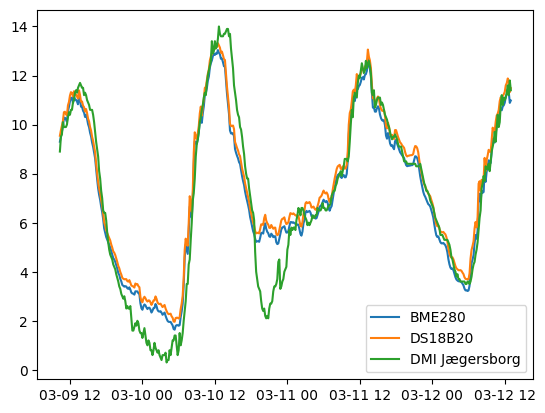

In [72]:
from matplotlib import pyplot as plt

t0 = max(min(dme280_resampled.index),min(ds_resampled.index),min(jaegersborg_data['timestamp']))
t1 = min(max(dme280_resampled.index),max(ds_resampled.index),max(jaegersborg_data['timestamp']))

series_dme = dme280_resampled.loc[t0:t1]
series_ds = ds_resampled.loc[t0:t1]
series_ja = jaegersborg_data.set_index('timestamp').loc[t0:t1]

plt.plot(series_dme.index, series_dme['temperature'], label='BME280')
plt.plot(series_ds.index, series_ds['temperature'], label='DS18B20')
plt.plot(series_ja.index, series_ja['temp_dry'], label='DMI Jægersborg')
plt.legend()